In [8]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import scipy
import os
import torch
from matplotlib import pyplot as plt
from umap import UMAP
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import sys; sys.path += ['./../../']
from CardamomOT import NetworkModel as CardamomNetworkModel
from CardamomOT import train_classifier, predict_cell_types
from CardamomOT.inference.simulations import kon_ref, simulate_next_prot_ode
from harissa import NetworkModel as HarissaNetworkModel

In [19]:
SOFT_COLORS = [
    '#4878CF', '#E87B30', '#6DB36D', '#C94040', '#8C6DBF',
    '#57A8A8', '#C97BAA', '#8C7B6B', '#9CBF57', '#CF9B3A',
]
REF_COLOR = '#555555'   # grey  — reference data
SIM_COLOR = '#C94040'   # red   — CardamomOT model

In [9]:
def load_cardamom_data(cardamom_path, n_per_time=25, umap_min_dist=0.7, umap_random_state=42, lognorm=True):
    rna_traj = np.load(f'{cardamom_path}/data_rna.npy')[:, 1:]
    G = rna_traj.shape[1]
    model = CardamomNetworkModel(G)
    
    model.d = np.load(f'{cardamom_path}/degradations.npy')
    model.basal = np.load(f'{cardamom_path}/basal_simul.npy')
    model.inter = np.load(f'{cardamom_path}/inter_simul.npy')
    model.kon_simul = np.load(f'{cardamom_path}/data_kon_simul.npy')
    model.a = np.load(f'{cardamom_path}/mixture_parameters.npy')
    model.pi = np.load(f'{cardamom_path}/pi_zinb.npy')
    time = np.load(f'{cardamom_path}/data_times.npy')
    
    # Subsample cells per time point
    np.random.seed(0)
    subsample_indices = []
    for t in np.unique(time):
        time_indices = np.where(time == t)[0]
        n_sample = min(n_per_time, len(time_indices))
        sampled = np.random.choice(time_indices, size=n_sample, replace=False)
        subsample_indices.extend(sampled)
    subsample_indices = np.array(subsample_indices)
    
    # Generate simulated data
    c = model.a[-1]
    ks_cells = np.max(model.a[:-1], axis=0)
    
    data_sim = np.random.negative_binomial(
        (ks_cells * model.kon_simul)[:, 1:].T,
        (c / (c + 1))[1:].reshape(G, 1),
    )
    zero_mask = (np.random.uniform(0, 1, data_sim.shape) < model.pi.reshape((G, 1)))
    print("new zeros ratio sim: ", np.sum(zero_mask == 1) / np.size(data_sim[1:, :]))
    data_sim = np.where(zero_mask, 0, data_sim).T
    
    return rna_traj, data_sim, time, model, subsample_indices

In [10]:
cardamom_path = '../../../../data/Datas_exp/Semrau/cardamom'
rna_traj_semrau, data_sim_semrau, time_semrau, model, subsample_semrau = load_cardamom_data(cardamom_path, n_per_time=100)
adata_semrau = sc.read(f'{cardamom_path}/../Data/data_full.h5ad')
adata_beta_semrau = sc.read(f'{cardamom_path}/adata_beta.h5ad')
adata_sim_semrau = sc.AnnData(X=data_sim_semrau)
adata_sim_semrau.obs['time'] = time_semrau
adata_sim_semrau.var_names = adata_semrau.var_names
clf = train_classifier(adata_semrau, label_key='cell_type')
adata_sim_semrau = predict_cell_types(adata_sim_semrau, clf)

new zeros ratio sim:  0.0


In [11]:
cardamom_path = '../../../../data/Datas_exp/Data_Olivier/cardamom'
rna_traj_olivier, data_sim_olivier, time_olivier, model, subsample_olivier = load_cardamom_data(cardamom_path, n_per_time=250)
adata_olivier = sc.read(f'{cardamom_path}/../Data/data_train.h5ad')
adata_beta_olivier = sc.read(f'{cardamom_path}/adata_beta.h5ad')
adata_sim_olivier = sc.AnnData(X=data_sim_olivier)
adata_sim_olivier.obs['time'] = time_olivier
adata_sim_olivier.var_names = adata_olivier.var_names
clf = train_classifier(adata_olivier, label_key='cell_type')
adata_sim_olivier = predict_cell_types(adata_sim_olivier, clf)

new zeros ratio sim:  0.0


In [12]:
cardamom_path = '../../../../data/Datas_exp/Schiebinger/cardamom'
rna_traj_schiebinger, data_sim_schiebinger, time_schiebinger, model, subsample_schiebinger = load_cardamom_data(cardamom_path, n_per_time=100)
adata_schiebinger = sc.read(f'{cardamom_path}/../Data/data_train.h5ad')
adata_beta_schiebinger = sc.read(f'{cardamom_path}/adata_beta.h5ad')
adata_sim_schiebinger = sc.AnnData(X=data_sim_schiebinger)
adata_sim_schiebinger.obs['time'] = time_schiebinger
adata_sim_schiebinger.var_names = adata_schiebinger.var_names
clf = train_classifier(adata_schiebinger, label_key='cell_type')
adata_sim_schiebinger = predict_cell_types(adata_sim_schiebinger, clf)

new zeros ratio sim:  0.0


In [30]:
def draw_hist(ax, vals_data, vals_sim, title, n_bins=22, show_legend=False, show_xlabel=True, show_ylabel=True):
    q99  = max(np.quantile(vals_data, 0.999), np.quantile(vals_sim, 0.99))
    bins = np.linspace(0, q99 + 1, n_bins)
    ax.hist(vals_data, density=True, bins=bins,
            color=REF_COLOR, alpha=0.45, histtype='bar')
    ax.hist(vals_sim,  density=True, bins=bins,
            ec=SIM_COLOR, histtype='step', lw=1.5)
    ax.set_title(title, fontsize=6.5, pad=2)
    if show_xlabel:
        ax.set_xlabel('mRNA (copies/cell)', fontsize=6, labelpad=2)
    if show_ylabel:
        ax.set_ylabel('Density', fontsize=6, labelpad=2)
    ax.tick_params(labelsize=5, pad=2)
    for sp in ax.spines.values():
        sp.set_linewidth(0.6)
    if show_legend:
        ax.legend(
            handles=[
                Line2D([0], [0], color=REF_COLOR, lw=2, label='Reference'),
                Line2D([0], [0], color=SIM_COLOR,  lw=2, label='Model'),
            ],
            fontsize=5, frameon=False, loc='upper right',
        )

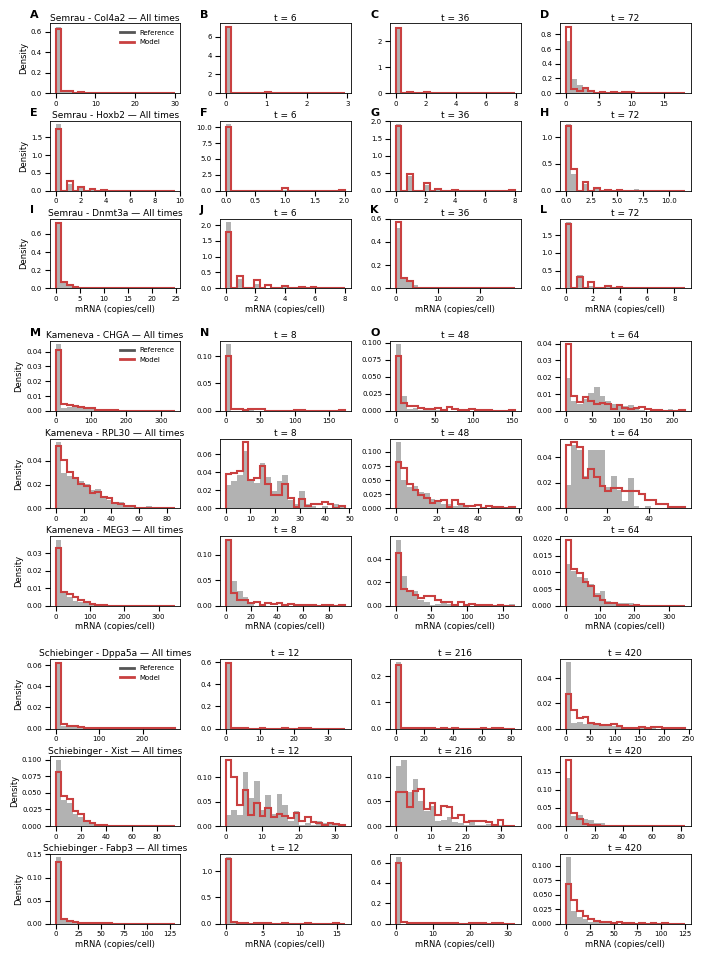

In [45]:
fig = plt.figure(figsize=(8.27, 11.69))
gs   = gridspec.GridSpec(3, 1, figure=fig, height_ratios=[1, 1, 1], width_ratios=[1],
                         hspace=0.2, wspace=0.28)
gs01 = gs[0, 0].subgridspec(3, 4, hspace=0.4, wspace=0.3)
gs02 = gs[1, 0].subgridspec(3, 4, hspace=0.4, wspace=0.3)
gs03 = gs[2, 0].subgridspec(3, 4, hspace=0.4, wspace=0.3)

axes = (
    [fig.add_subplot(gs01[r, c]) for r in range(3) for c in range(4)] +
    [fig.add_subplot(gs02[r, c]) for r in range(3) for c in range(4)] +
    [fig.add_subplot(gs03[r, c]) for r in range(3) for c in range(4) ]
)

for ax, label in zip(axes, "ABCDEFGHIJKLMNO"):
    ax.text(-0.15, 1.05, label, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=8, fontweight="bold", clip_on=False)

gene_plot_configs = [
    (axes[0:12],  adata_semrau,      data_sim_semrau,      time_semrau,      [4, 18, 6],      "Semrau"),
    (axes[12:24], adata_olivier,     data_sim_olivier,     time_olivier,     [12, 72, 45],    "Kameneva"),
    (axes[24:36], adata_schiebinger, data_sim_schiebinger, time_schiebinger, [24, 105, 33],   "Schiebinger"),
]

for ax_slice, adata_ref, x_sim, t_sim, hist_genes, dataset_name in gene_plot_configs:
    x_ref = adata_ref.X.toarray() if scipy.sparse.issparse(adata_ref.X) else np.array(adata_ref.X)
    t_ref = np.array(adata_ref.obs["time"])

    # 4 columns: first timepoint + next 3 timepoints
    ut = np.sort(np.unique(t_ref))
    t0 = ut[0]
    sel_times = ut[[1, len(ut) // 2, -2]]

    ax_grid = np.array(ax_slice).reshape(3, 4)

    for row, g in enumerate(hist_genes[:3]):
        gname = adata_ref.var_names[g]

        # First column
        draw_hist(
            ax_grid[row, 0],
            x_ref[:, g],
            x_sim[:, g],
            f"{dataset_name} - {gname} — All times",
            show_legend=(row == 0),
            show_xlabel=(row == 2),
            show_ylabel=True,
        )

        # Next 3 columns
        for col, tp in enumerate(sel_times, start=1):
            draw_hist(
                ax_grid[row, col],
                x_ref[t_ref == tp, g],
                x_sim[t_sim == tp, g],
                f"t = {tp:g}",
                show_xlabel=(row == 2),
                show_ylabel=False,
            )

plt.savefig('figure_s4.pdf', dpi=300, bbox_inches='tight')
plt.show()